# Semester Assignment 2

## Dynamic surrogate model for the pervaporation module

The goal is to replace a slow, rigorous process model with a faster regression model. The surrogate receives four time-dependent process inputs and predicts two outputs: the ethanol mass fraction and the temperature at the module outlet.

Group A Members:
- Philo Odermatt 521059
- Jonah Sontag 410828
- Siqi He 519748
- Pascal Kising 375086

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer,
)


# General settings used throughout the notebook
DATA_PATH = "../PV_training_data.pkl"
TEST_FRACTION = 0.10
TIME_STEP_SECONDS = 10
LAG_OPTIONS = [2, 3, 5]
RANDOM_STATE = 42


# The pickle file contains two DataFrames with the same time index:
# controls: four process inputs; outputs: two values to be predicted.
with open(DATA_PATH, "rb") as file:
    data = pickle.load(file)

controls = data["controls"]
outputs = data["outputs"]

print(f"Controls: {controls.shape[0]} time steps, {controls.shape[1]} variables")
print(f"Outputs:  {outputs.shape[0]} time steps, {outputs.shape[1]} variables")


Controls: 20021 time steps, 4 variables
Outputs:  20021 time steps, 2 variables


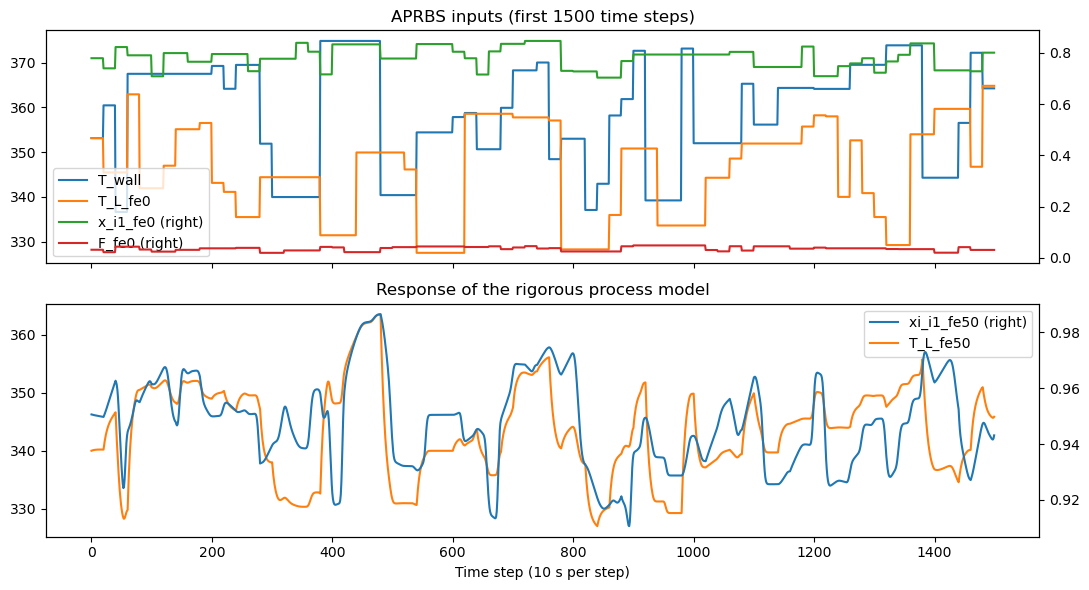

In [14]:
# Plot a short section of the data to show the changing APRBS inputs
# and the delayed, smooth response of the physical process.
N_DISPLAY_STEPS = 1500

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

controls.iloc[:N_DISPLAY_STEPS].plot(
    ax=axes[0],
    secondary_y=["x_i1_fe0", "F_fe0"],
)
outputs.iloc[:N_DISPLAY_STEPS].plot(
    ax=axes[1],
    secondary_y=["xi_i1_fe50"],
)

axes[0].set_title("APRBS inputs (first 1500 time steps)")
axes[1].set_title("Response of the rigorous process model")
axes[1].set_xlabel("Time step (10 s per step)")

plt.tight_layout()
plt.show()


## 1. Building a dynamic training dataset

A static regression model would only connect the inputs at one time step with the outputs at the same time step. This is not sufficient here: the module reacts with a delay, so its current output also depends on its previous state.

We therefore use a NARX-style feature structure. To predict the outputs at time step `k`, the model receives:

- previous outputs: `y[k-1]` to `y[k-lag]`
- previous controls: `u[k-1]` to `u[k-lag]`

The tested lag orders are 2, 3, and 5. The same lag order is used for controls and outputs to keep the comparison simple.

The final 10% of the time series are reserved as one chronological test set. During training and cross-validation, the models perform one-step-ahead predictions using the measured previous outputs. The final test is more demanding: it is one continuous autoregressive rollout in which each prediction becomes an input for the next prediction.

All input features and both targets are standardized inside the model pipeline. This prevents information from the validation data entering the preprocessing. It also ensures that the mass fraction (about 0.95) and the temperature (about 340 K) are treated on comparable scales.


In [15]:
def build_narx_dataset(controls, outputs, n_lags):
    """Create lagged features for one-step-ahead prediction.

    For every time step k, the features contain previous outputs and controls.
    The target is the measured output at time step k.
    """
    feature_blocks = []

    # Add previous output values first: y[k-1], y[k-2], ...
    for lag in range(1, n_lags + 1):
        lagged_outputs = outputs.shift(lag).copy()
        lagged_outputs.columns = [f"{column}_lag{lag}" for column in outputs.columns]
        feature_blocks.append(lagged_outputs)

    # Add previous control values next: u[k-1], u[k-2], ...
    for lag in range(1, n_lags + 1):
        lagged_controls = controls.shift(lag).copy()
        lagged_controls.columns = [f"{column}_lag{lag}" for column in controls.columns]
        feature_blocks.append(lagged_controls)

    lagged_features = pd.concat(feature_blocks, axis=1)

    # The first n_lags rows have incomplete histories and cannot be used.
    lagged_features = lagged_features.iloc[n_lags:]
    current_outputs = outputs.iloc[n_lags:]

    return lagged_features, current_outputs


def get_feature_names(n_lags):
    """Return the exact feature order used by build_narx_dataset."""
    output_names = [
        f"{column}_lag{lag}"
        for lag in range(1, n_lags + 1)
        for column in outputs.columns
    ]
    control_names = [
        f"{column}_lag{lag}"
        for lag in range(1, n_lags + 1)
        for column in controls.columns
    ]
    return output_names + control_names


def mean_normalized_rmse(y_true, y_pred):
    """Average the RMSE of both targets after normalizing by their spread."""
    rmse_per_target = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    target_standard_deviation = np.std(y_true, axis=0)
    return np.mean(rmse_per_target / target_standard_deviation)


# GridSearchCV maximizes a score. greater_is_better=False tells it that a
# smaller normalized RMSE is better and automatically changes the sign.
normalized_rmse_scorer = make_scorer(
    mean_normalized_rmse,
    greater_is_better=False,
)

# The last 10% form the test set. They are never used for tuning.
n_test_steps = int(len(outputs) * TEST_FRACTION)
test_start = len(outputs) - n_test_steps

# TimeSeriesSplit preserves the chronological order in every validation fold.
time_series_cv = TimeSeriesSplit(n_splits=3)


def make_scaled_model(regression_model):
    """Scale the lagged features and both targets within each CV fold."""
    feature_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", regression_model),
    ])

    return TransformedTargetRegressor(
        regressor=feature_pipeline,
        transformer=StandardScaler(),
    )


## 2. Models and hyperparameter tuning

The search compares two levels of model complexity:

- ARX-LASSO: a linear dynamic model. LASSO can reduce unimportant coefficients through regularization.
- NARX-MLP: a nonlinear dynamic model with one or two hidden neural-network layers.

The lag order is also a hyperparameter. A lag order of 5 means that the model uses the previous five samples of each signal.

| Model | Hyperparameters searched |
|---|---|
| ARX-LASSO | lags `{2, 3, 5}` and nine values of `alpha` |
| NARX-MLP | lags `{2, 3, 5}`, two network sizes, two activation functions and three values of `alpha` |



In [16]:
# Each entry contains a fresh model and the parameters to be tuned.
model_definitions = {
    "ARX-LASSO": {
        "model": make_scaled_model(Lasso(max_iter=50_000)),
        "parameter_grid": {
            "regressor__regressor__alpha": np.logspace(-5, -1, 9),
        },
    },
    "NARX-MLP": {
        "model": make_scaled_model(
            MLPRegressor(
                solver="adam",
                max_iter=800,
                early_stopping=True,
                random_state=RANDOM_STATE,
            )
        ),
        "parameter_grid": {
            "regressor__regressor__hidden_layer_sizes": [(64,), (64, 32)],
            "regressor__regressor__activation": ["relu", "tanh"],
            "regressor__regressor__alpha": [1e-4, 1e-3, 1e-2],
        },
    },
}


best_models = {}

for model_name, definition in model_definitions.items():
    print(f"\n{model_name}")

    # Running minimum: remember the best candidate seen so far.
    best_error = np.inf
    best_lag = None
    best_estimator = None
    best_parameters = None

    for n_lags in LAG_OPTIONS:
        features, targets = build_narx_dataset(controls, outputs, n_lags)

        # Remove the chronological test block before any model fitting or tuning.
        training_features = features.iloc[:-n_test_steps]
        training_targets = targets.iloc[:-n_test_steps]

        search = GridSearchCV(
            estimator=definition["model"],
            param_grid=definition["parameter_grid"],
            cv=time_series_cv,
            scoring=normalized_rmse_scorer,
            n_jobs=-1,
        )
        search.fit(training_features, training_targets)

        validation_score = -search.best_score_

        print(f"Lags {n_lags}: CV normalized RMSE = {validation_score:.4f}")
        print(f"    Best parameters: {search.best_params_}")

        # Keep this candidate if it beats the previous best.
        if validation_score < best_error:
            best_error = validation_score
            best_lag = n_lags
            best_estimator = search.best_estimator_
            best_parameters = search.best_params_

    best_models[model_name] = (best_lag, best_estimator)

    print(f"    -> Selected lag order: {best_lag}")
    print(f"    -> Selected parameters: {best_parameters}")


ARX-LASSO
Lags 2: CV normalized RMSE = 0.0128
    Best parameters: {'regressor__regressor__alpha': np.float64(1e-05)}
Lags 3: CV normalized RMSE = 0.0107
    Best parameters: {'regressor__regressor__alpha': np.float64(1e-05)}
Lags 5: CV normalized RMSE = 0.0105
    Best parameters: {'regressor__regressor__alpha': np.float64(1e-05)}
    -> Selected lag order: 5
    -> Selected parameters: {'regressor__regressor__alpha': np.float64(1e-05)}

NARX-MLP
Lags 2: CV normalized RMSE = 0.0309
    Best parameters: {'regressor__regressor__activation': 'tanh', 'regressor__regressor__alpha': 0.01, 'regressor__regressor__hidden_layer_sizes': (64,)}
Lags 3: CV normalized RMSE = 0.0418
    Best parameters: {'regressor__regressor__activation': 'tanh', 'regressor__regressor__alpha': 0.01, 'regressor__regressor__hidden_layer_sizes': (64, 32)}
Lags 5: CV normalized RMSE = 0.0370
    Best parameters: {'regressor__regressor__activation': 'tanh', 'regressor__regressor__alpha': 0.01, 'regressor__regressor__hi

## 3. Autoregressive multi-step prediction

The required test is one continuous prediction over all 2,002 test steps.

At the beginning, the model receives the measured outputs immediately before the test period. These values provide the initial process state. After that, no measured test outputs are used:

1. The model predicts the next mass fraction and temperature.
2. These two predictions are added to the output history.
3. The updated history is used to predict the following time step.
4. This is repeated until the complete test profile has been predicted.


In [17]:
def autoregressive_rollout(model, n_lags):
    """Predict the complete test set while feeding predictions back as history."""
    # Only measured values from before the test period initialize the model.
    output_history = outputs.iloc[test_start - n_lags:test_start].to_numpy().copy()
    predictions = np.zeros((n_test_steps, len(outputs.columns)))

    for prediction_index, time_index in enumerate(range(test_start, len(outputs))):
        # Reverse both histories so that lag 1 comes before lag 2, and so on.
        previous_outputs = output_history[::-1].reshape(-1)
        previous_controls = (
            controls.iloc[time_index - n_lags:time_index]
            .to_numpy()[::-1]
            .reshape(-1)
        )

        model_input = np.concatenate([previous_outputs, previous_controls])
        model_input = pd.DataFrame(
            [model_input],
            columns=get_feature_names(n_lags),
        )

        next_prediction = model.predict(model_input)[0]
        predictions[prediction_index] = next_prediction

        # Drop the oldest output and append the new prediction.
        output_history = np.vstack([output_history[1:], next_prediction])

    return pd.DataFrame(
        predictions,
        index=outputs.index[test_start:],
        columns=outputs.columns,
    )


metric_rows = []
rollout_predictions = {}

for model_name, (n_lags, model) in best_models.items():
    features, targets = build_narx_dataset(controls, outputs, n_lags)
    test_features = features.loc[test_start:]
    test_targets = targets.loc[test_start:]

    # One-step prediction uses measured output histories from the test data.
    one_step_prediction = pd.DataFrame(
        model.predict(test_features),
        index=test_targets.index,
        columns=outputs.columns,
    )

    # The rollout uses only its own previous predictions after initialization.
    rollout_prediction = autoregressive_rollout(model, n_lags)
    rollout_predictions[model_name] = rollout_prediction

    for target_name in outputs.columns:
        metric_rows.append({
            "Model": model_name,
            "Target": target_name,
            "One-step RMSE": mean_squared_error(
                test_targets[target_name],
                one_step_prediction[target_name],
            ) ** 0.5,
            "Rollout RMSE": mean_squared_error(
                test_targets[target_name],
                rollout_prediction[target_name],
            ) ** 0.5,
            "Rollout MAE": mean_absolute_error(
                test_targets[target_name],
                rollout_prediction[target_name],
            ),
            "Rollout R2": r2_score(
                test_targets[target_name],
                rollout_prediction[target_name],
            ),
        })


results = (
    pd.DataFrame(metric_rows)
    .set_index(["Model", "Target"])
    .round(4)
)
print(results)


                      One-step RMSE  Rollout RMSE  Rollout MAE  Rollout R2
Model     Target                                                          
ARX-LASSO xi_i1_fe50         0.0003        0.0076       0.0055      0.8109
          T_L_fe50           0.0634        1.2553       0.8980      0.9768
NARX-MLP  xi_i1_fe50         0.0005        0.0175       0.0139     -0.0057
          T_L_fe50           0.1641        2.6008       2.1229      0.9005


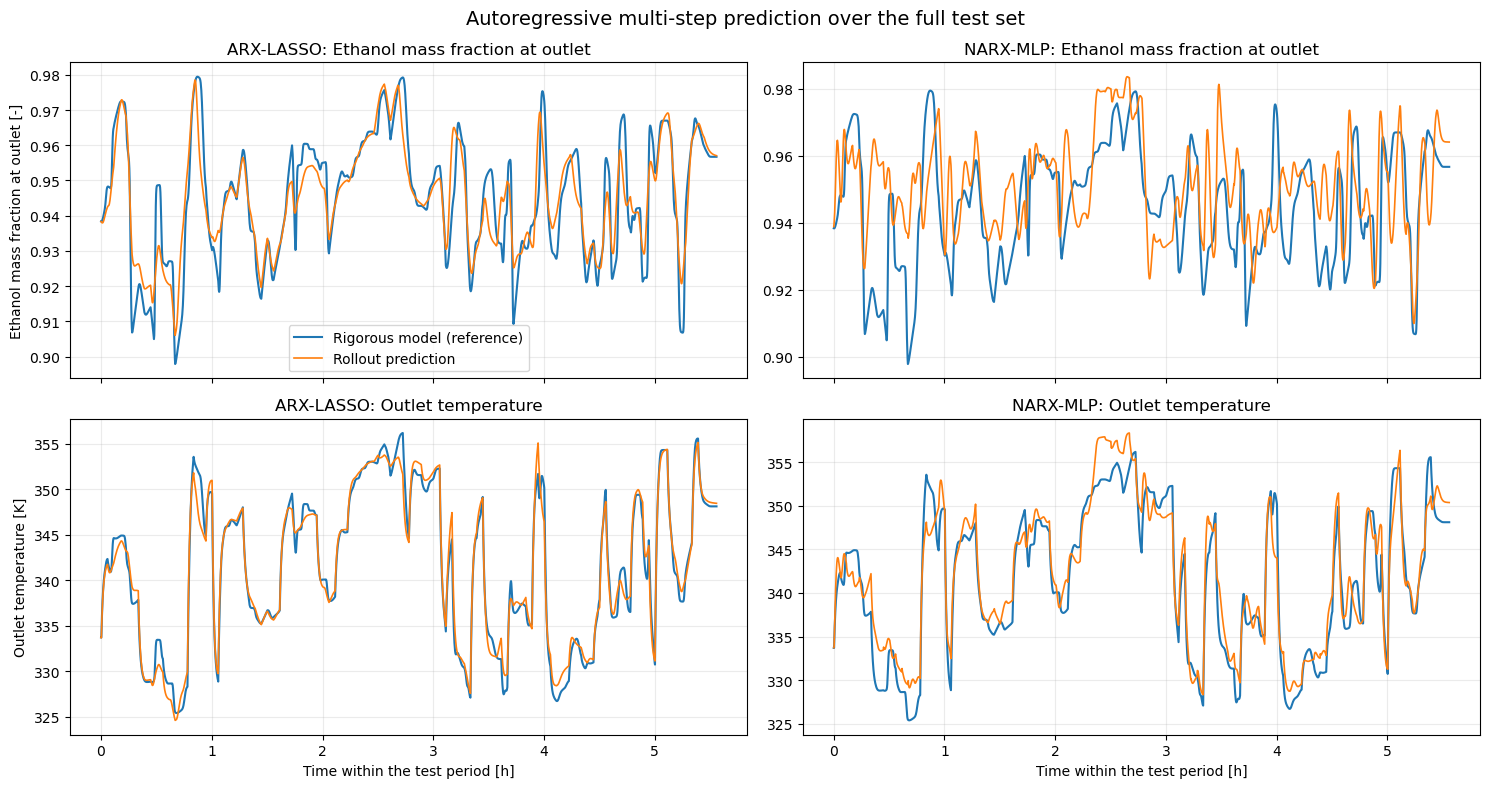

In [19]:
# Plot the complete autoregressive rollout for both targets and models
# in a 2x2 grid: one column per model, one row per target.
truth = outputs.iloc[test_start:]
test_time_hours = np.arange(n_test_steps) * TIME_STEP_SECONDS / 3600

target_labels = {
    "xi_i1_fe50": ("Ethanol mass fraction at outlet", "-"),
    "T_L_fe50": ("Outlet temperature", "K"),
}

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

for column_index, (model_name, rollout) in enumerate(rollout_predictions.items()):
    for row_index, target_name in enumerate(outputs.columns):
        display_name, unit = target_labels[target_name]
        axis = axes[row_index, column_index]

        axis.plot(
            test_time_hours,
            truth[target_name],
            label="Rigorous model (reference)",
            linewidth=1.5,
        )
        axis.plot(
            test_time_hours,
            rollout[target_name],
            label="Rollout prediction",
            linewidth=1.2,
        )

        axis.set_title(f"{model_name}: {display_name}")
        axis.grid(alpha=0.25)

        if row_index == 1:
            axis.set_xlabel("Time within the test period [h]")
        if column_index == 0:
            axis.set_ylabel(f"{display_name} [{unit}]")

axes[0, 0].legend()
fig.suptitle("Autoregressive multi-step prediction over the full test set", fontsize=14)
fig.tight_layout()
plt.show()

## 4. Discussion

### Main result

Both models are very accurate when they only predict one step ahead. This shows that the lagged inputs and outputs contain enough information to describe the short-term process dynamics. However, the continuous rollout is the more important test because every prediction is reused at the next step and errors can accumulate.

The linear ARX-LASSO model performs best in this test:

- outlet temperature: RMSE = 1.26 K and R² = 0.977
- ethanol mass fraction: RMSE = 0.0076 and R² = 0.81

The NARX-MLP still describes the temperature reasonably well with an R² of 0.9. Its mass-fraction predictions are less stable, however, and the rollout R² is signifcantly worse. The plot shows that its deviations are repeatedly fed back into the model instead of reliably decreasing.

### Interpretation

The best LASSO value for `alpha` is the smallest value in the tested grid. Therefore, only very weak regularization is needed and the selected model behaves similarly to an ordinary linear ARX model. The strong rollout performance suggests that the pervaporation module is approximately linear within the operating range covered by the APRBS data.

For ARX-LASSO, five previous time steps give the best validation result. The MLP selects only two previous steps. A larger history gives the linear model more information, while the additional feedback dimensions do not improve the neural network.

### Final model choice

ARX-LASSO with five lags is selected as the final surrogate model. It has the smallest rollout errors, remains stable over the complete 5.6-hour test period, and is much cheaper to evaluate than the neural network. Fast evaluation is particularly useful for the intended NMPC application.
